In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import emoji
import string
import re

In [2]:
df = pd.read_csv("goud_articles.csv")
df.head()

,title,url,category,content,published_time,modified_time
0,استعدادا للمونديال.. حموشي عين مسؤولين أمنيين ...,https://www.goud.ma/%d8%ad%d9%85%d9%88%d8%b4%d...,آش واقع,أنس العمري-كود///\nأشر المدير العام للأمن الوط...,2025-08-06 20:12:57+00:00,2025-08-06T21:00:07+00:00
1,قرار محكمة العدل الاوربية. وزير خارجية الصبليو...,https://www.goud.ma/%d9%82%d8%b1%d8%a7%d8%b1-%...,آش واقع,مدريد و م ع///\nأعرب وزير الشؤون الخارجية الاس...,2024-10-04 15:43:02+00:00,NaN
2,تحديد مواعيد مؤجلات الرجا وليفار وبركان وماتشا...,https://www.goud.ma/%d8%aa%d8%ad%d8%af%d9%8a%d...,كود سبور,كود سبور//\nحددت العصبة الوطنية لكرة القدم الا...,2025-01-12 21:06:45+00:00,NaN
3,الأرصاد الجوية: الصهد فهاد المناطق والغيام فال...,https://www.goud.ma/%d8%a7%d9%84%d8%a3%d8%b1%d...,آش واقع,عمر المزين – كود//\nتوقعات المديرية العامة للأ...,2025-05-06 08:48:42+00:00,NaN
4,تقرير: نتنياهو باغي يعرض خطط جديدة لضرب إيران ...,https://www.goud.ma/%d8%aa%d9%82%d8%b1%d9%8a%d...,جورنالات بلادي,وكالات//\nتستعد إسرائيل لطرح ملف حساس على طاول...,2025-12-20 22:00:55+00:00,2025-12-20T22:03:12+00:00


In [3]:
df = df.drop(["url", "published_time", "modified_time"], axis=1)

In [4]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 8241
Total Features (columns): 3


In [5]:
print(df.dtypes)

title       str
category    str
content     str
dtype: object


In [6]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])
if (duplicate_count > 0):
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate values detected in the data.")

2 Duplicate values found in the data.


In [7]:
#Check null values
missing = df.isnull().sum()
print("Missing Values : ", missing[missing > 0])

Missing Values :  content    7
dtype: int64


In [8]:
df.dropna(inplace=True)

In [9]:
df["category"].unique()

<ArrowStringArray>
[       'آش واقع',       'كود سبور', 'جورنالات بلادي',   'ميديا وثقافة',
       'الرئيسية',         'تبركيك',           'آراء',       'كود-تيفي',
 'الزين والحداكة',      'راس السوق',            'كود']
Length: 11, dtype: str

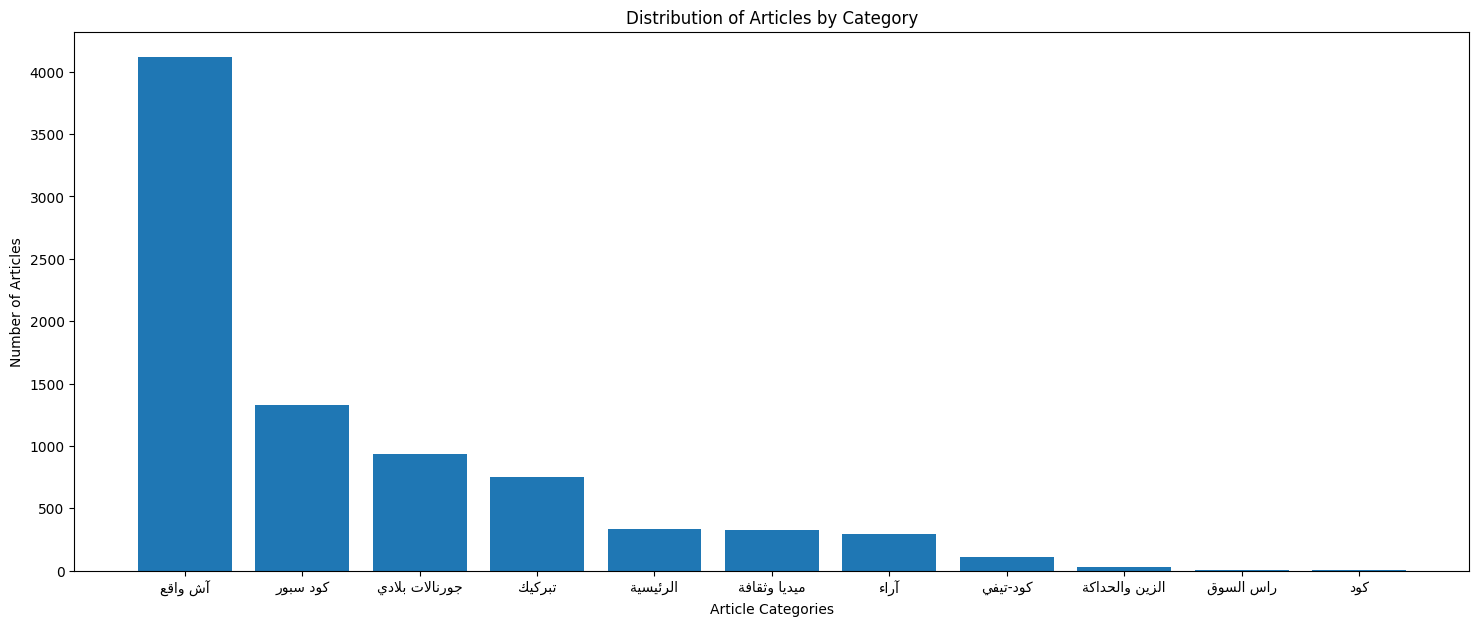

In [10]:
categories_count = df["category"].value_counts()
categories = categories_count.keys().to_list()

for i, category in enumerate(categories):
    categories[i] = get_display(arabic_reshaper.reshape(category))

plt.figure(figsize=(18, 7))
plt.bar(categories, categories_count.values)
plt.title("Distribution of Articles by Category")
plt.xlabel("Article Categories")
plt.ylabel("Number of Articles")
plt.show()

In [11]:
def clean_first_line(text):
    lines = text.split('\n')
    if '/' in lines[0]:
        return '\n'.join(lines[1:]).strip()
    return text

original = df["content"].copy()
df["content"] = df["content"].apply(clean_first_line)

counter = (df["content"] != original).sum()
print(f"Cleaned: {counter}")

Cleaned: 8205


In [12]:
print(f"Empty strings: {(df['content'] == '').sum()}")

Empty strings: 8


In [13]:
df = df[df["content"].str.strip() != ""]

In [14]:
def get_first_paragraph(text, min_words=15):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    
    result = ""
    word_count = 0

    for line in lines:
        result += " " + line
        word_count += len(line.split())
        if word_count >= min_words:
            break

    return result.strip()

In [15]:
df["first_paragraph"] = df["content"].apply(get_first_paragraph)

In [16]:
for i in range(5):
    print(df["first_paragraph"].iloc[i])
    print("_____________" * 10)

أشر المدير العام للأمن الوطني، عبد اللطيف حموشي، ظهر اليوم الأربعاء، على قائمة جديدة تتضمن تعيين 24 مسؤولا جديدا في مناصب المسؤولية للتدبير الإداري والعملياتي للمصالح المركزية والجهوية للأمن الوطني.
__________________________________________________________________________________________________________________________________
أعرب وزير الشؤون الخارجية الاسباني، خوسي مانويل ألباريس، اليوم الجمعة، عن احترام حكومة بلاده لقرار محكمة العدل الأوروبية المتعلق باتفاقيتي الفلاحة والصيد البحري بين الاتحاد الأوروبي والمغرب، مدافعا في نفس الوقت عن “الشراكة الاستراتيجية” مع المملكة المغربية ومؤكدا إرادة الحفاظ عليها.
__________________________________________________________________________________________________________________________________
حددت العصبة الوطنية لكرة القدم الاحترافية، مواعيد الماتشات المؤجلة عن الجولتين 17 و 18 و 19 بالنسبة للفرق اللي مشاركة فالمسابقات الافريقية.
___________________________________________________________________________________________________________________

In [17]:
df["first_paragraph_length"] = df["first_paragraph"].apply(len)
df["first_paragraph_length"].describe()

count    8223.000000
mean      223.711298
std       203.832881
min        68.000000
25%       156.000000
50%       197.000000
75%       248.000000
max      6087.000000
Name: first_paragraph_length, dtype: float64

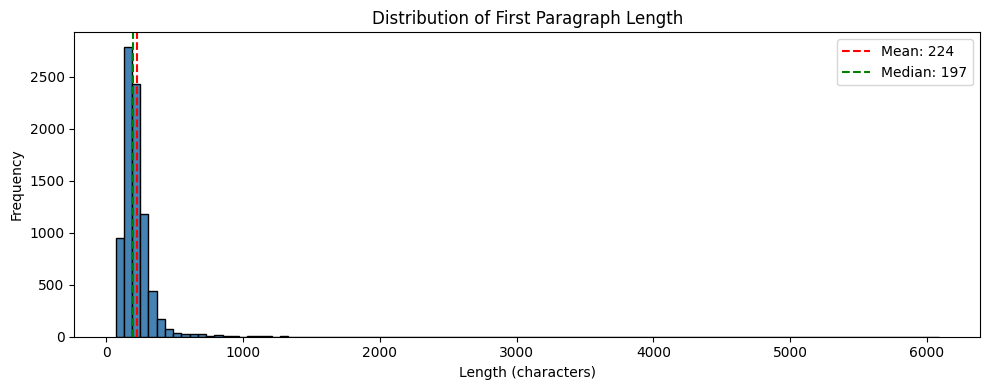

In [18]:
plt.figure(figsize=(10, 4))
plt.hist(df["first_paragraph_length"], bins=100, color='steelblue', edgecolor='black')
plt.title("Distribution of First Paragraph Length")
plt.xlabel("Length (characters)")
plt.ylabel("Frequency")
plt.axvline(df["first_paragraph_length"].mean(), color='red', linestyle='--', label=f'Mean: {df["first_paragraph_length"].mean():.0f}')
plt.axvline(df["first_paragraph_length"].median(), color='green', linestyle='--', label=f'Median: {df["first_paragraph_length"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# The data is right-skewed (many short texts, few very long ones)

# Compute quartiles
Q1 = df["first_paragraph_length"].quantile(0.25)
Q3 = df["first_paragraph_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)

df = df[(df["first_paragraph_length"] >= lower_bound) &
        (df["first_paragraph_length"] <= upper_bound)]

after = len(df)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

print(f"Before: {before}")
print(f"After:  {after}")
print(f"Removed: {before - after}")

Q1: 156.00
Q3: 248.00
IQR: 92.00
Lower bound: 18.00
Upper bound: 386.00
Before: 8223
After:  7860
Removed: 363


In [20]:
df["first_paragraph_length"].describe()

count    7860.000000
mean      200.269466
std        62.704772
min        68.000000
25%       154.000000
50%       193.000000
75%       238.000000
max       386.000000
Name: first_paragraph_length, dtype: float64

In [21]:
for i in range(5000):
    print(df["first_paragraph"].iloc[i])
    print("_" * 149)

أشر المدير العام للأمن الوطني، عبد اللطيف حموشي، ظهر اليوم الأربعاء، على قائمة جديدة تتضمن تعيين 24 مسؤولا جديدا في مناصب المسؤولية للتدبير الإداري والعملياتي للمصالح المركزية والجهوية للأمن الوطني.
_____________________________________________________________________________________________________________________________________________________
أعرب وزير الشؤون الخارجية الاسباني، خوسي مانويل ألباريس، اليوم الجمعة، عن احترام حكومة بلاده لقرار محكمة العدل الأوروبية المتعلق باتفاقيتي الفلاحة والصيد البحري بين الاتحاد الأوروبي والمغرب، مدافعا في نفس الوقت عن “الشراكة الاستراتيجية” مع المملكة المغربية ومؤكدا إرادة الحفاظ عليها.
_____________________________________________________________________________________________________________________________________________________
حددت العصبة الوطنية لكرة القدم الاحترافية، مواعيد الماتشات المؤجلة عن الجولتين 17 و 18 و 19 بالنسبة للفرق اللي مشاركة فالمسابقات الافريقية.
_____________________________________________________________________________

In [22]:
def extract_patterns_global(df, column="first_paragraph"):
    PATTERNS = {
        "urls":               r'http[s]?://\S+|www\.\S+',
        "emails":             r'[\w.+-]+@[\w-]+\.[a-z]{2,}',
        "emojis":             r'[\U00010000-\U0010ffff]|[\u2600-\u27BF]|[\uFE00-\uFE0F]',
        "arabic_punctuation": r'[،؛؟٪٫٬]',
        "latin_punctuation":  r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]',
        "arabic_numbers":     r'[٠-٩]+',
        "latin_numbers":      r'\d+',
        "dates":              r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{1,2}\s*(نونبر|أكتوبر|يناير|فبراير|مارس|أبريل|ماي|يونيو|يوليوز|غشت|شتنبر|دجنبر)',
        "latin_words":        r'\b[a-zA-Z]{2,}\b',
        "invisible_chars":    r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]',
        "hashtags":           r'#\w+',
        "mentions":           r'@\w+',
        "phone_numbers":      r'(?:\+212|0)[5-7]\d{8}',
        "extra_spaces":       r' {2,}',
        "newlines":           r'\n+',
    }

    features = {name: set() for name in PATTERNS}

    for text in df[column].dropna():
        for name, pattern in PATTERNS.items():
            matches = re.findall(pattern, str(text), flags=re.IGNORECASE)
            features[name].update(matches)  # update() adds each element individually

    return features

features = extract_patterns_global(df)
for key, values in features.items():
    print(f"{key}: {len(values)} found → {values}")

urls: 2 found → {'https://www.facebook.com/watch/?mibextid=WC7FNe&share_url=https%3A%2F%2Fwww.facebook.com%2Fshare%2Fv%2F19bC9LQVRy%2F%3Fmibextid%3DWC7FNe&v=599937695712500&rdid=jWUbt0BpbYbNOMNM', 'https://web.facebook.com/Goudmediaa/videos/1057250823048478'}
emails: 0 found → set()
emojis: 0 found → set()
arabic_punctuation: 6 found → {'٬', '؛', '٫', '،', '؟', '٪'}
latin_punctuation: 15 found → {')', '=', ',', '.', '%', '/', '_', '!', ':', '-', '?', '|', '@', '&', '('}
arabic_numbers: 0 found → set()
latin_numbers: 452 found → {'69', '399', '26', '49', '2037', '2250', '630', '645', '1952', '5507', '202', '85', '81', '2003', '658', '2025', '2115', '301', '174', '132', '34', '242', '106', '5895', '267', '93622', '77', '4', '40', '64', '47', '359', '625', '1995', '30', '73', '156', '103', '2008', '255', '98', '6161', '2082', '07', '4880', '43', '230', '2015', '08', '27', '1182', '1966', '400', '1999', '127', '5500', '820', '7412', '967', '186', '3067', '340', '4781', '65', '1000', '466',

In [23]:
def clean_darija_text(text):
    text = str(text)
    
    # 1. Remove invisible characters
    text = re.sub(r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]', '', text)
    # 2. Remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    # 3. Remove mentions
    text = re.sub(r'@\w+', '', text)    
    # 5. Remove extra spaces
    text = re.sub(r' {2,}', ' ', text)
    # 6. Strip
    text = text.strip()
    
    return text

df["first_paragraph"] = df["first_paragraph"].apply(clean_darija_text)

In [24]:
df.head()

,title,category,content,first_paragraph,first_paragraph_length
0,استعدادا للمونديال.. حموشي عين مسؤولين أمنيين ...,آش واقع,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,198
1,قرار محكمة العدل الاوربية. وزير خارجية الصبليو...,آش واقع,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,283
2,تحديد مواعيد مؤجلات الرجا وليفار وبركان وماتشا...,كود سبور,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,139
3,الأرصاد الجوية: الصهد فهاد المناطق والغيام فال...,آش واقع,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,236
4,تقرير: نتنياهو باغي يعرض خطط جديدة لضرب إيران ...,جورنالات بلادي,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,386


In [26]:
df.rename(columns={"first_paragraph": "context"}, inplace=True)
df["context"].to_csv('context.csv', index=False)